# 02 — Làm sạch dữ liệu (Data Cleaning)

**Bối cảnh:** đề mới là **clustering** — `salary` giờ là **feature** (không phải target). Quy trình ở đây phục vụ pipeline phân cụm.

**Mục tiêu:** áp các quyết định từ [01_EDA.ipynb](./01_EDA.ipynb) lên dữ liệu thô để sinh ra `clean_data_train.csv` và `clean_data_test.csv` — sạch về mặt ngữ nghĩa (không còn junk), nhưng **chưa làm feature engineering** (việc đó ở stage 3).

**Quy tắc nguyên tắc của bước này:**

1. **Không leak:** mọi tham số (`junk_buckets`, `TOP_INDUSTRIES`…) đều được **fit trên train sample 150k**, sau đó áp dụng nguyên xi cho test và cho full train.
2. **Không impute statistic:** giá trị thiếu để `NaN` — stage 3 (feature engineering) sẽ quyết định cách impute phù hợp.
3. **Drop có chủ đích, có log:** mỗi bước drop dòng đều in `n_before / n_after / % giảm` để dễ kiểm chứng.
4. **`salary` là feature, không phải target:**
   - Tách thành 3 cột numeric: `salary_min`, `salary_max`, `salary_mid` (= `(min+max)/2`).
   - Dòng không parse được (thoả thuận / đang cập nhật / 0 VND…): **GIỮ LẠI** với flag `salary_missing=True`, 3 cột numeric = NaN.
   - DROP dòng có sentinel `... -999.000.000 VND` + dòng `salary_mid > 100M` không sentinel (outlier scale phá K-Means).
5. **Memory:** train raw CSV nay là 1.1 GB — viz dùng sample 150k, apply final dùng **chunked read + write incremental** lên full data.

**Input:** `../raw_data/raw_data_{train,test}.csv` (split 90/10).
**Output:** `../clean_data/clean_data_{train,test}.csv` — 17 cột.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 140)

ROOT = Path.cwd().parent
RAW_DIR = ROOT / 'raw_data'
CLEAN_DIR = ROOT / 'clean_data'
CLEAN_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
USD_TO_VND = 25_000
SALARY_SCALE_LIMIT = 100        # triệu VNĐ — drop dòng > ngưỡng này không có sentinel (outlier scale phá K-Means)
TOP_K_INDUSTRY = 50             # giữ top-50 ngành base, còn lại gom vào 'Other'
EXP_JUNK_MIN_N = 500            # bucket years_exp có < ngưỡng & pos_missing cao → junk
EXP_JUNK_POS_RATE = 0.5
SAMPLE_SIZE = 150_000           # train sample để fit tham số + viz; cleaning final chạy full chunked
CHUNK_SIZE = 50_000             # batch size khi xử lý full train (1.1 GB)

## 1. Đọc dữ liệu thô

- **Test** (123 MB, 60,688 dòng): load full.
- **Train** (1.1 GB, 546,190 dòng): load **SAMPLE 150k** cho viz/fit-params. Final cleaning sẽ áp full chunked ở Section 7.

In [2]:
def count_rows(path):
    with open(path, encoding='utf-8-sig') as f:
        return sum(1 for _ in f) - 1


N_TRAIN_FULL = count_rows(RAW_DIR / 'raw_data_train.csv')
N_TEST_FULL = count_rows(RAW_DIR / 'raw_data_test.csv')

rng_skip = np.random.RandomState(RANDOM_STATE)
n_skip = max(0, N_TRAIN_FULL - SAMPLE_SIZE)
skip_idx = set(rng_skip.choice(np.arange(1, N_TRAIN_FULL + 1), size=n_skip, replace=False).tolist())

train_raw = pd.read_csv(RAW_DIR / 'raw_data_train.csv',
                        skiprows=lambda i: i > 0 and i in skip_idx)
test_raw = pd.read_csv(RAW_DIR / 'raw_data_test.csv')

print(f"Full dataset: train = {N_TRAIN_FULL:,} | test = {N_TEST_FULL:,} (split 90/10)")
print(f"Sample đang dùng cho viz/fit: train = {len(train_raw):,} | test = {len(test_raw):,}")
print(f"Columns: {list(train_raw.columns)}")

train = train_raw.copy()
test = test_raw.copy()

Full dataset: train = 546,190 | test = 60,688 (split 90/10)
Sample đang dùng cho viz/fit: train = 150,000 | test = 60,688
Columns: ['id', 'job_title', 'company_name', 'salary', 'location', 'job_type', 'job_industry', 'experience_level', 'education_level', 'job_position', 'job_description', 'benefits', 'requirements', 'year']


## 2. Parse `salary` thành 3 feature numeric

Áp các pattern đã chốt ở EDA Section 2.2. Khác với bản regression (parse thành 1 cột target `expected_salary`), bản clustering tách thành **3 feature numeric**:

- `salary_min`, `salary_max`: 2 đầu của dải lương (triệu VNĐ).
- `salary_mid = (min + max) / 2`: lương trung bình.
- `salary_missing`: flag boolean cho biết dòng đó không parse được salary.

**Quyết định drop** (xem EDA Section 2.5):
- DROP dòng có sentinel `... -999.000.000 VND` (junk chắc chắn).
- DROP dòng `salary_mid > 100M` không sentinel (outlier scale phá K-Means).
- **GIỮ** dòng không parse được (thoả thuận, đang cập nhật, 0 VND…) — flag `salary_missing=True`, 3 cột numeric = NaN, stage 3 sẽ impute median.

In [3]:
PATTERNS = {
    'vnd_range_dotted':  re.compile(r'^([\d.]+)\s*-\s*([\d.]+)\s*VND$'),
    'vnd_range_month':   re.compile(r'^(\d+)\s*-\s*(\d+)\s*VND MONTH$'),
    'vnd_single_dotted': re.compile(r'^([\d.]+)\s*VND$'),
    'usd_range':         re.compile(r'\$?\s*(\d+)\s*-\s*\$?\s*(\d+)\s*USD', re.IGNORECASE),
}

SENTINEL_RE = re.compile(r'-\s*999\.000\.000\s*VND$')


def parse_salary_to_minmaxmid(s):
    """Parse cột salary thành (min, max, mid) triệu VNĐ. (NaN, NaN, NaN) nếu không parse được."""
    if not isinstance(s, str):
        return (np.nan, np.nan, np.nan)

    m = PATTERNS['vnd_range_dotted'].search(s)
    if m:
        lo = int(m.group(1).replace('.', '')) / 1e6
        hi = int(m.group(2).replace('.', '')) / 1e6
        if lo == 0 and hi == 0:
            return (np.nan, np.nan, np.nan)
        return (lo, hi, (lo + hi) / 2)

    m = PATTERNS['vnd_range_month'].search(s)
    if m:
        lo = int(m.group(1)) / 1e6
        hi = int(m.group(2)) / 1e6
        if lo == 0 and hi == 0:
            return (np.nan, np.nan, np.nan)
        return (lo, hi, (lo + hi) / 2)

    m = PATTERNS['vnd_single_dotted'].search(s)
    if m:
        v = int(m.group(1).replace('.', '')) / 1e6
        if v == 0:
            return (np.nan, np.nan, np.nan)
        return (v, v, v)

    m = PATTERNS['usd_range'].search(s)
    if m:
        lo = int(m.group(1)) * USD_TO_VND / 1e6
        hi = int(m.group(2)) * USD_TO_VND / 1e6
        return (lo, hi, (lo + hi) / 2)

    return (np.nan, np.nan, np.nan)


def apply_salary_parse(df):
    """Tạo 3 cột numeric salary_{min,max,mid} + flag salary_missing. Trả về DataFrame mới."""
    df = df.copy()
    parsed = df['salary'].map(parse_salary_to_minmaxmid)
    df[['salary_min', 'salary_max', 'salary_mid']] = pd.DataFrame(
        parsed.tolist(), index=df.index)
    df['salary_missing'] = df['salary_mid'].isna()
    return df


train = apply_salary_parse(train)
test = apply_salary_parse(test)

In [4]:
def salary_diagnostic(df, name):
    n = len(df)
    parsed = df['salary_mid'].notna().sum()
    has_sent = df['salary'].astype(str).str.contains(SENTINEL_RE, regex=True, na=False)
    n_sent = int(has_sent.sum())
    n_high = int((df['salary_mid'] > SALARY_SCALE_LIMIT).sum())
    n_sent_high = int((has_sent & (df['salary_mid'] > SALARY_SCALE_LIMIT)).sum())
    n_high_no_sent = n_high - n_sent_high
    print(f"{name:5s}: n={n:>7,} | parsed={parsed:>7,} ({parsed/n*100:.2f}%) | "
          f"sentinel={n_sent:>4,} | >{SALARY_SCALE_LIMIT}M no-sent={n_high_no_sent:>4,}")


print("Trước khi filter outlier:")
salary_diagnostic(train, 'train')
salary_diagnostic(test, 'test')

Trước khi filter outlier:
train: n=150,000 | parsed=141,680 (94.45%) | sentinel=  10 | >100M no-sent= 181
test : n= 60,688 | parsed= 57,454 (94.67%) | sentinel=   5 | >100M no-sent=  77


In [5]:
def filter_salary_outliers(df, name):
    """Drop sentinel + drop >100M không sentinel. GIỮ dòng salary_missing=True (flag-based)."""
    n0 = len(df)
    has_sentinel = df['salary'].astype(str).str.contains(SENTINEL_RE, regex=True, na=False)
    is_outlier_no_sent = (~has_sentinel) & (df['salary_mid'] > SALARY_SCALE_LIMIT)
    drop_mask = has_sentinel | is_outlier_no_sent
    df = df.loc[~drop_mask].copy()
    n1 = len(df)
    n_missing = int(df['salary_missing'].sum())
    print(f"{name:5s}: {n0:>7,} → drop sentinel+outlier: {n0-n1:>5,} → còn {n1:>7,} "
          f"({n1/n0*100:.2f}%). Trong đó salary_missing=True (giữ + flag): {n_missing:>6,} "
          f"({n_missing/n1*100:.2f}%)")
    return df


train = filter_salary_outliers(train, 'train')
test = filter_salary_outliers(test, 'test')

print(f"\nThống kê `salary_mid` (train, triệu VNĐ; chỉ dòng parsed được):")
print(train['salary_mid'].describe().round(2).to_string())

train: 150,000 → drop sentinel+outlier:   191 → còn 149,809 (99.87%). Trong đó salary_missing=True (giữ + flag):  8,320 (5.55%)
test :  60,688 → drop sentinel+outlier:    82 → còn  60,606 (99.86%). Trong đó salary_missing=True (giữ + flag):  3,234 (5.34%)

Thống kê `salary_mid` (train, triệu VNĐ; chỉ dòng parsed được):
count    141489.00
mean         13.33
std           6.79
min           0.15
25%           9.00
50%          12.00
75%          15.00
max         100.00


### Trực quan — phân phối `salary_mid` trước/sau filter

So sánh phân phối **trước** (toàn bộ parse-được) và **sau** (drop sentinel + drop >100M không sentinel) trên train sample. Phần đuôi >100M biến mất hoàn toàn — các outlier scale từng ở mức 800-900M (sentinel) đều đã bị loại.

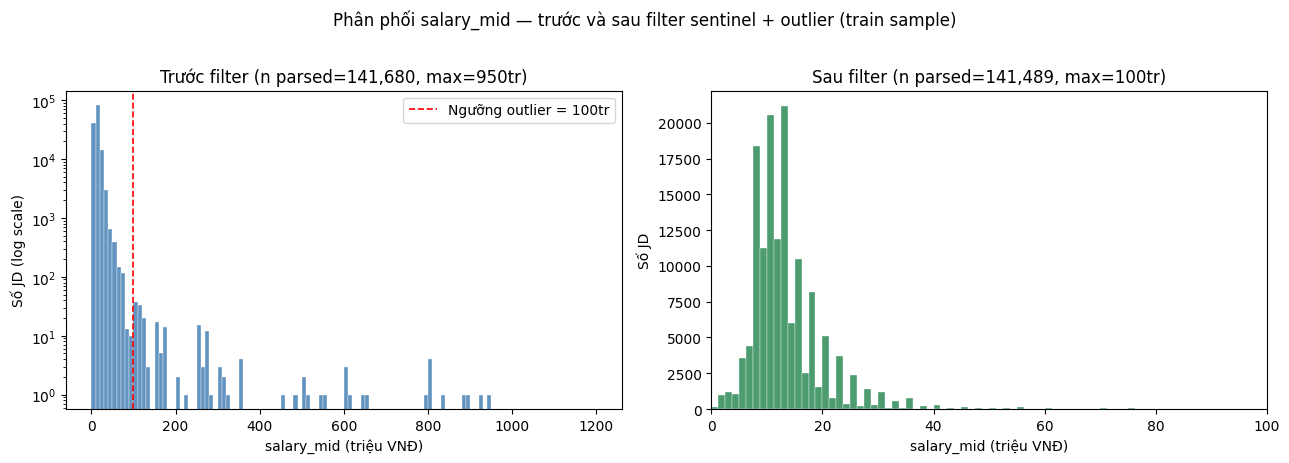

Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\cleaning_salary_distribution.png


In [6]:
import matplotlib.pyplot as plt

FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

salary_before_parsed = train_raw['salary'].map(
    lambda s: parse_salary_to_minmaxmid(s)[2]).dropna()
salary_after = train['salary_mid'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.hist(salary_before_parsed, bins=120, range=(0, 1200),
        color='steelblue', alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(SALARY_SCALE_LIMIT, color='red', linestyle='--', lw=1.2,
           label=f'Ngưỡng outlier = {SALARY_SCALE_LIMIT}tr')
ax.set_yscale('log')
ax.set_xlabel('salary_mid (triệu VNĐ)')
ax.set_ylabel('Số JD (log scale)')
ax.set_title(f'Trước filter (n parsed={len(salary_before_parsed):,}, '
             f'max={salary_before_parsed.max():.0f}tr)')
ax.legend()

ax = axes[1]
ax.hist(salary_after, bins=80, range=(0, 100),
        color='seagreen', alpha=0.85, edgecolor='white', linewidth=0.3)
ax.set_xlabel('salary_mid (triệu VNĐ)')
ax.set_ylabel('Số JD')
ax.set_title(f'Sau filter (n parsed={len(salary_after):,}, '
             f'max={salary_after.max():.0f}tr)')
ax.set_xlim(0, 100)

plt.suptitle('Phân phối salary_mid — trước và sau filter sentinel + outlier (train sample)', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cleaning_salary_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIG_DIR / 'cleaning_salary_distribution.png'}")

## 3. Trích `years_exp` từ `experience_level`

Regex `(\d+)\s*năm`. Bucket junk được phát hiện bằng luật (xem EDA Section 7.2.1):
> `n_rows < 500` VÀ `pos_missing_rate > 0.5` → coi là junk → set `years_exp = NaN`.

Tham số `junk_buckets` được **fit trên train sample**, áp dụng nguyên cho test và cho full train (Section 7).

In [7]:
def extract_years(s):
    if not isinstance(s, str):
        return np.nan
    s = s.strip()
    if 'Dưới 1' in s:
        return 0.5
    if s in {'Không', 'Chưa cập nhật', 'Không yêu cầu'}:
        return np.nan
    m = re.search(r'(\d+)\s*năm', s)
    return float(m.group(1)) if m else np.nan


train['years_exp'] = train['experience_level'].map(extract_years)
test['years_exp'] = test['experience_level'].map(extract_years)

In [8]:
df_diag = train.dropna(subset=['years_exp']).copy()
df_diag['_pos_missing'] = (df_diag['job_position'] == 'Chưa cập nhật')

exp_stats = df_diag.groupby('years_exp').agg(
    n_rows=('id', 'size'),
    median_salary=('salary_mid', 'median'),
    pos_missing_rate=('_pos_missing', 'mean'),
).round(3)

junk_buckets = exp_stats[
    (exp_stats['n_rows'] < EXP_JUNK_MIN_N)
    & (exp_stats['pos_missing_rate'] > EXP_JUNK_POS_RATE)
].index.tolist()

print("Cấu trúc theo years_exp (train sample):")
print(exp_stats.to_string())
print(f"\nBucket bị nhận diện là junk (fit trên sample): {junk_buckets}")

Cấu trúc theo years_exp (train sample):
           n_rows  median_salary  pos_missing_rate
years_exp                                         
0.5          1718           10.0             0.227
1.0         40271           10.5             0.096
2.0         23271           11.0             0.077
3.0         43872           11.5             0.065
4.0         20342           13.5             0.058
5.0         10303           16.0             0.055
6.0           745           17.5             0.054
7.0          2510           19.5             0.065
8.0          1003           22.5             0.051
9.0            66            8.5             1.000
10.0           39            NaN             0.000
20.0            4            NaN             0.000

Bucket bị nhận diện là junk (fit trên sample): [9.0]


In [9]:
for df, name in [(train, 'train'), (test, 'test')]:
    n_before = df['years_exp'].notna().sum()
    df.loc[df['years_exp'].isin(junk_buckets), 'years_exp'] = np.nan
    n_after = df['years_exp'].notna().sum()
    print(f"{name:5s}: years_exp non-null {n_before:>7,} → {n_after:>7,} (giảm {n_before-n_after})")

print(f"\nPhân phối years_exp sau lọc (train):")
print(train['years_exp'].value_counts().sort_index().to_string())

train: years_exp non-null 144,144 → 144,078 (giảm 66)
test : years_exp non-null  58,308 →  58,284 (giảm 24)

Phân phối years_exp sau lọc (train):
years_exp
0.5      1718
1.0     40271
2.0     23271
3.0     43872
4.0     20342
5.0     10303
6.0       745
7.0      2510
8.0      1003
10.0       39
20.0        4


### Trực quan — bucket `years_exp` & nhận diện junk

Bar chart số lượng + median lương theo bucket năm KN, **highlight đỏ** bucket bị rule-based nhận diện là junk (`n<500` & `pos_missing>0.5`).

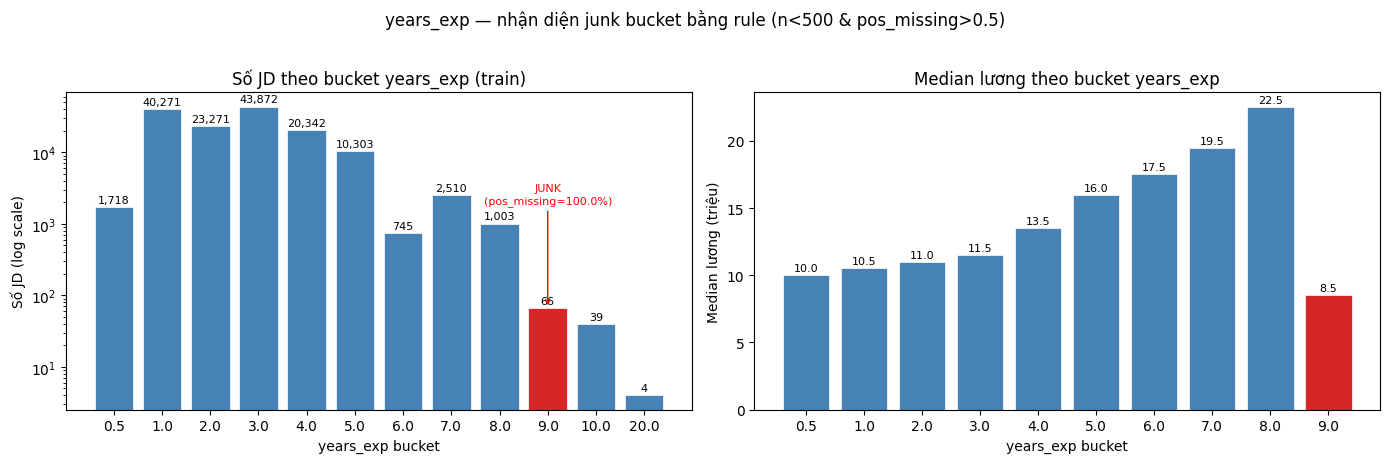

Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\cleaning_years_exp_buckets.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

buckets = exp_stats.index.astype(str).tolist()
colors = ['tab:red' if float(b) in junk_buckets else 'steelblue' for b in buckets]

ax = axes[0]
ax.bar(buckets, exp_stats['n_rows'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_yscale('log')
ax.set_xlabel('years_exp bucket')
ax.set_ylabel('Số JD (log scale)')
ax.set_title('Số JD theo bucket years_exp (train)')
for i, (b, n) in enumerate(zip(buckets, exp_stats['n_rows'])):
    ax.text(i, n * 1.15, f'{n:,}', ha='center', fontsize=8)
# annotation cho junk
junk_idx = [i for i, b in enumerate(buckets) if float(b) in junk_buckets]
for i in junk_idx:
    ax.annotate(
        f'JUNK\n(pos_missing={exp_stats["pos_missing_rate"].iloc[i]:.1%})',
        xy=(i, exp_stats['n_rows'].iloc[i]),
        xytext=(i, exp_stats['n_rows'].iloc[i] * 30),
        ha='center', fontsize=8, color='red',
        arrowprops=dict(arrowstyle='->', color='red', lw=1),
    )

ax = axes[1]
ax.bar(buckets, exp_stats['median_salary'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('years_exp bucket')
ax.set_ylabel('Median lương (triệu)')
ax.set_title('Median lương theo bucket years_exp')
for i, (b, m) in enumerate(zip(buckets, exp_stats['median_salary'])):
    ax.text(i, m + 0.3, f'{m:.1f}', ha='center', fontsize=8)

plt.suptitle('years_exp — nhận diện junk bucket bằng rule (n<500 & pos_missing>0.5)', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cleaning_years_exp_buckets.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIG_DIR / 'cleaning_years_exp_buckets.png'}")

## 4. Trích `province` từ `location`

Regex 2 lớp:
- **Lớp 1:** tìm tên 63 tỉnh/thành trong chuỗi.
- **Lớp 2 (fallback):** tra tên quận/huyện của HCM và Hà Nội nếu lớp 1 fail.

Không match được → `'Other'`.

In [11]:
VN_PROVINCES = [
    'Hồ Chí Minh', 'Hà Nội', 'Đà Nẵng', 'Hải Phòng', 'Cần Thơ',
    'An Giang', 'Bà Rịa - Vũng Tàu', 'Bắc Giang', 'Bắc Kạn', 'Bạc Liêu',
    'Bắc Ninh', 'Bến Tre', 'Bình Định', 'Bình Dương', 'Bình Phước',
    'Bình Thuận', 'Cà Mau', 'Cao Bằng', 'Đắk Lắk', 'Đắk Nông',
    'Điện Biên', 'Đồng Nai', 'Đồng Tháp', 'Gia Lai', 'Hà Giang',
    'Hà Nam', 'Hà Tĩnh', 'Hải Dương', 'Hậu Giang', 'Hòa Bình',
    'Hưng Yên', 'Khánh Hòa', 'Kiên Giang', 'Kon Tum', 'Lai Châu',
    'Lâm Đồng', 'Lạng Sơn', 'Lào Cai', 'Long An', 'Nam Định',
    'Nghệ An', 'Ninh Bình', 'Ninh Thuận', 'Phú Thọ', 'Phú Yên',
    'Quảng Bình', 'Quảng Nam', 'Quảng Ngãi', 'Quảng Ninh', 'Quảng Trị',
    'Sóc Trăng', 'Sơn La', 'Tây Ninh', 'Thái Bình', 'Thái Nguyên',
    'Thanh Hóa', 'Thừa Thiên Huế', 'Tiền Giang', 'Trà Vinh', 'Tuyên Quang',
    'Vĩnh Long', 'Vĩnh Phúc', 'Yên Bái',
]

DISTRICT_TO_PROVINCE = {
    **{f'Quận {i}': 'Hồ Chí Minh' for i in range(1, 13)},
    'Tân Bình': 'Hồ Chí Minh', 'Bình Thạnh': 'Hồ Chí Minh',
    'Phú Nhuận': 'Hồ Chí Minh', 'Gò Vấp': 'Hồ Chí Minh',
    'Thủ Đức': 'Hồ Chí Minh', 'Hóc Môn': 'Hồ Chí Minh',
    'Củ Chi': 'Hồ Chí Minh', 'Nhà Bè': 'Hồ Chí Minh',
    'Bình Chánh': 'Hồ Chí Minh', 'Cần Giờ': 'Hồ Chí Minh',
    'Tân Phú': 'Hồ Chí Minh', 'Bình Tân': 'Hồ Chí Minh',
    'Hoàn Kiếm': 'Hà Nội', 'Ba Đình': 'Hà Nội', 'Đống Đa': 'Hà Nội',
    'Cầu Giấy': 'Hà Nội', 'Thanh Xuân': 'Hà Nội',
    'Hai Bà Trưng': 'Hà Nội', 'Tây Hồ': 'Hà Nội',
    'Long Biên': 'Hà Nội', 'Hà Đông': 'Hà Nội',
    'Nam Từ Liêm': 'Hà Nội', 'Bắc Từ Liêm': 'Hà Nội',
    'Hoàng Mai': 'Hà Nội',
}

_PROVINCE_RE = re.compile('|'.join(re.escape(p) for p in VN_PROVINCES), re.IGNORECASE)
_DISTRICT_RE = re.compile('|'.join(re.escape(d) for d in DISTRICT_TO_PROVINCE), re.IGNORECASE)
_LOOKUP = {p.lower(): p for p in VN_PROVINCES}
_LOOKUP.update({k.lower(): v for k, v in DISTRICT_TO_PROVINCE.items()})


def extract_province(s):
    if not isinstance(s, str):
        return 'Other'
    m = _PROVINCE_RE.search(s)
    if m:
        return _LOOKUP[m.group(0).lower()]
    m = _DISTRICT_RE.search(s)
    if m:
        return _LOOKUP[m.group(0).lower()]
    return 'Other'


train['province'] = train['location'].map(extract_province)
test['province'] = test['location'].map(extract_province)

In [12]:
for df, name in [(train, 'train'), (test, 'test')]:
    coverage = (df['province'] != 'Other').mean()
    print(f"{name:5s}: coverage {coverage:.2%} | unique = {df['province'].nunique()} | "
          f"Other = {(df['province'] == 'Other').sum():,}")

print(f"\nTop 10 province (train):")
print(train['province'].value_counts().head(10).to_string())

train: coverage 94.07% | unique = 64 | Other = 8,888
test : coverage 94.04% | unique = 64 | Other = 3,613

Top 10 province (train):
province
Hồ Chí Minh    66717
Hà Nội         38882
Other           8888
Bình Dương      6920
Đồng Nai        3098
Long An         2491
Đà Nẵng         2449
Điện Biên       1965
Bình Phước      1679
Bắc Ninh        1405


### Trực quan — top 15 tỉnh/thành (train)

Bar ngang top 15 + nhóm 'Other' (cell không match được regex 2 lớp). HCM + Hà Nội chiếm phần lớn — phản ánh thị trường tuyển dụng tập trung 2 thành phố.

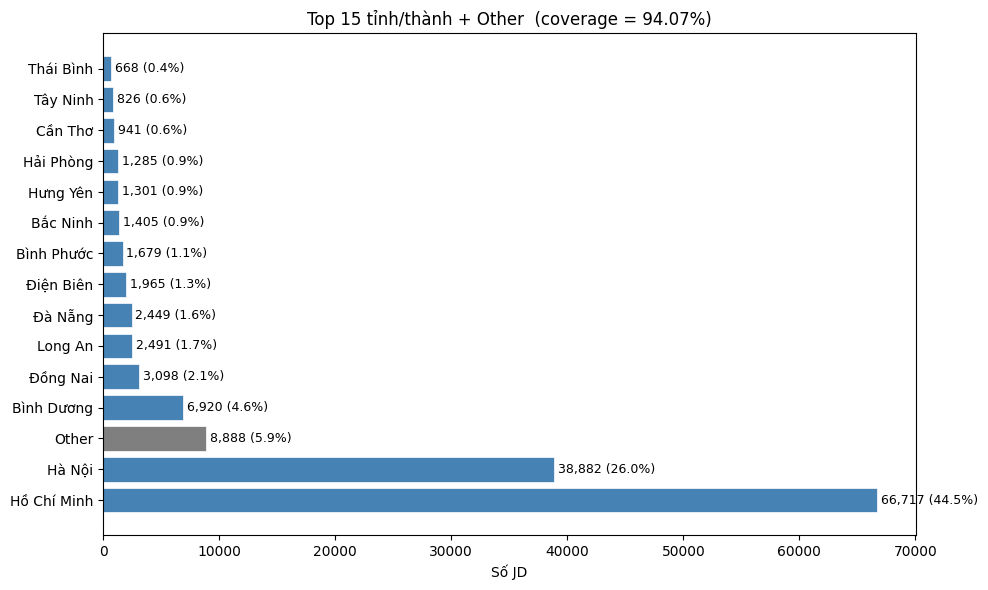

Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\cleaning_province_top15.png


In [13]:
prov_counts = train['province'].value_counts()
top_n = 15
top = prov_counts.head(top_n)
other_count = prov_counts.iloc[top_n:].sum() + (prov_counts.get('Other', 0) - prov_counts.get('Other', 0))
# Đảm bảo 'Other' luôn xuất hiện ở cuối
if 'Other' not in top.index:
    top = pd.concat([top, pd.Series({'Other': prov_counts.get('Other', 0)})])

pct = top / len(train) * 100

fig, ax = plt.subplots(figsize=(10, 6))
colors_p = ['tab:gray' if name == 'Other' else 'steelblue' for name in top.index]
y_pos = np.arange(len(top))[::-1]
ax.barh(y_pos, top.values, color=colors_p, edgecolor='white', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(top.index)
ax.set_xlabel('Số JD')
ax.set_title(f'Top {top_n} tỉnh/thành + Other  (coverage = {(train["province"] != "Other").mean()*100:.2f}%)')
for i, (n, p) in enumerate(zip(top.values, pct.values)):
    ax.text(n + max(top.values) * 0.005, y_pos[i], f'{n:,} ({p:.1f}%)', va='center', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / 'cleaning_province_top15.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIG_DIR / 'cleaning_province_top15.png'}")

## 5. `job_industry` → `industries_list` (multi-label)

Tách dấu `/` → list ngành base. Giữ top-50 ngành phổ biến nhất (fit trên train), còn lại gom vào `'Other'`. Lưu thành chuỗi nối bằng `|` cho gọn trong CSV.

In [14]:
def split_industries(s):
    if not isinstance(s, str):
        return []
    return [x.strip() for x in s.split('/') if x.strip()]


train_lists = train['job_industry'].map(split_industries)
all_base = pd.Series([ind for lst in train_lists for ind in lst])
top_k = all_base.value_counts().head(TOP_K_INDUSTRY)
TOP_INDUSTRIES = set(top_k.index)

print(f"Tổng số token base trên train: {len(all_base):,}")
print(f"Số ngành base unique         : {all_base.nunique():,}")
print(f"Top {TOP_K_INDUSTRY} ngành cover         : {top_k.sum() / len(all_base) * 100:.2f}%")
print(f"\n5 ngành phổ biến nhất:")
print(top_k.head(5).to_string())

Tổng số token base trên train: 207,439
Số ngành base unique         : 873
Top 50 ngành cover         : 96.79%

5 ngành phổ biến nhất:
Chăm sóc khách hàng      18368
Bán hàng - Kinh doanh    15295
Kế toán                  12654
Kiểm toán                12365
Giáo dục - Đào tạo        8820


In [15]:
def filter_industries(s):
    inds = split_industries(s)
    if not inds:
        return 'Other'
    kept = [ind if ind in TOP_INDUSTRIES else 'Other' for ind in inds]
    # khử trùng lặp, giữ thứ tự xuất hiện
    seen = []
    for x in kept:
        if x not in seen:
            seen.append(x)
    return '|'.join(seen)


train['industries_list'] = train['job_industry'].map(filter_industries)
test['industries_list'] = test['job_industry'].map(filter_industries)

n_industries_per_row = train['industries_list'].str.split('|').str.len()
print(f"Số ngành trên mỗi bài (train) — phân phối:")
print(n_industries_per_row.value_counts().sort_index().to_string())
print(f"\nTỉ lệ row chỉ có 'Other': {(train['industries_list'] == 'Other').mean():.2%}")

Số ngành trên mỗi bài (train) — phân phối:
industries_list
1    96980
2    51096
3     1732
4        1

Tỉ lệ row chỉ có 'Other': 1.77%


### Trực quan — top 20 ngành (multi-label, train)

Mỗi JD có 1–3 ngành (đã in distribution ở cell trên), nên tổng % > 100%. Bar chart % JD chứa ngành đó. So sánh thêm median lương theo ngành để thấy spread.

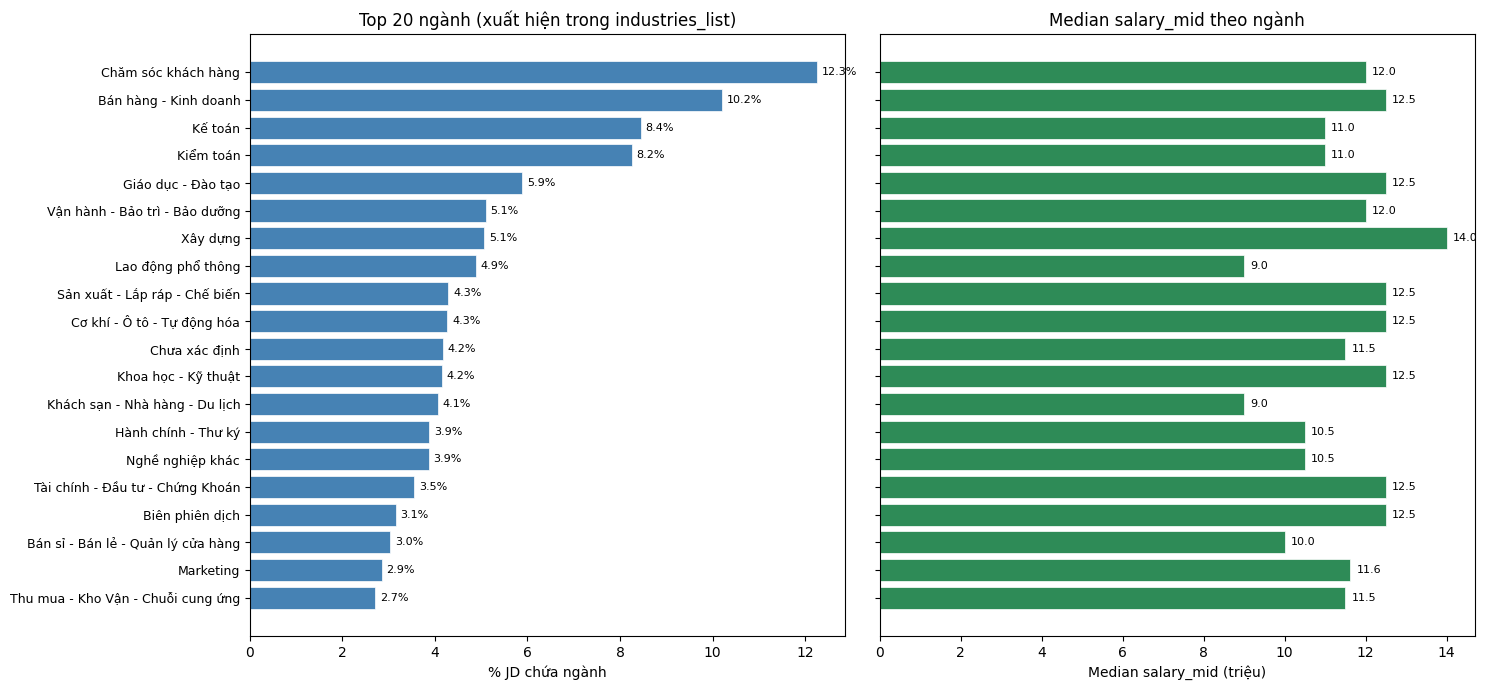

Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\cleaning_industries_top20.png


In [16]:
ind_exploded = train.assign(_ind=train['industries_list'].str.split('|')).explode('_ind')
ind_counts = ind_exploded['_ind'].value_counts()
ind_median = ind_exploded.groupby('_ind')['salary_mid'].median()

top_n = 20
top_ind = ind_counts.head(top_n).index.tolist()
ind_pct = (ind_counts.loc[top_ind] / len(train) * 100).round(2)
ind_med = ind_median.loc[top_ind].round(2)

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

y_pos = np.arange(len(top_ind))[::-1]
colors_i = ['tab:gray' if name == 'Other' else 'steelblue' for name in top_ind]

ax = axes[0]
ax.barh(y_pos, ind_pct.values, color=colors_i, edgecolor='white', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_ind, fontsize=9)
ax.set_xlabel('% JD chứa ngành')
ax.set_title(f'Top {top_n} ngành (xuất hiện trong industries_list)')
for i, p in enumerate(ind_pct.values):
    ax.text(p + 0.1, y_pos[i], f'{p:.1f}%', va='center', fontsize=8)
ax.invert_yaxis()

ax = axes[1]
ax.barh(y_pos, ind_med.values, color='seagreen', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Median salary_mid (triệu)')
ax.set_title('Median salary_mid theo ngành')
for i, m in enumerate(ind_med.values):
    ax.text(m + 0.15, y_pos[i], f'{m:.1f}', va='center', fontsize=8)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_DIR / 'cleaning_industries_top20.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIG_DIR / 'cleaning_industries_top20.png'}")

## 6. Chuẩn hoá categorical & text

- **Categorical ngắn** (`education_level`, `job_type`, `job_position`): `lower().strip()`, giá trị thiếu → `'unknown'`.
- **Text dài** (`job_title`, `company_name`, `job_description`, `requirements`, `benefits`): `strip()`, NaN → `''`. Không lowercase ở đây — stage 3 sẽ lowercase trong vectorizer.

In [17]:
def normalize_cat(s):
    if not isinstance(s, str):
        return 'unknown'
    s = s.strip().lower()
    return s if s else 'unknown'


for col in ['education_level', 'job_type', 'job_position']:
    for df in (train, test):
        df[col] = df[col].map(normalize_cat)

for col in ['job_title', 'company_name', 'job_description', 'requirements', 'benefits']:
    for df in (train, test):
        df[col] = df[col].fillna('').astype(str).str.strip()

print("Cardinality sau normalize (train):")
for col in ['education_level', 'job_type', 'job_position']:
    print(f"  {col:18s}: {train[col].nunique():>3}")

print("\nTỉ lệ rỗng text (train):")
for col in ['job_title', 'company_name', 'job_description', 'requirements', 'benefits']:
    empty = (train[col] == '').mean()
    print(f"  {col:18s}: {empty*100:5.2f}%")

Cardinality sau normalize (train):
  education_level   :  10
  job_type          :  17
  job_position      :  53

Tỉ lệ rỗng text (train):
  job_title         :  0.00%
  company_name      :  0.01%
  job_description   :  0.00%
  requirements      :  0.62%
  benefits          :  0.66%


## 7. Áp dụng cleaning lên FULL data + lưu CSV

Các tham số đã fit (`junk_buckets`, `TOP_INDUSTRIES`) từ Section 3-6 sẽ được áp lên:
- **Test** (61k dòng, 123 MB): load full → clean → save.
- **Train** (546k dòng, 1.1 GB): **chunked read** (50k row/batch) → clean → write incremental sang CSV. Tránh OOM.

Tất cả transform được gói trong `clean_chunk(df)` — stateless theo chunk vì mọi tham số fit đều là module-scope.

In [18]:
FINAL_COLUMNS = [
    'id',
    'salary_min', 'salary_max', 'salary_mid', 'salary_missing',
    'years_exp', 'year',
    'province', 'industries_list',
    'education_level', 'job_type', 'job_position',
    'job_title', 'company_name',
    'job_description', 'requirements', 'benefits',
]


def clean_chunk(df_chunk):
    """Áp toàn bộ transform stage 2 lên 1 DataFrame. Stateless theo chunk —
    mọi tham số fit (junk_buckets, TOP_INDUSTRIES) đều ở module scope."""
    df = df_chunk.copy()

    # 1. Salary: 3 feature + flag
    parsed = df['salary'].map(parse_salary_to_minmaxmid)
    df[['salary_min', 'salary_max', 'salary_mid']] = pd.DataFrame(
        parsed.tolist(), index=df.index)
    df['salary_missing'] = df['salary_mid'].isna()

    # 2. Drop sentinel + drop outlier non-sentinel
    has_sentinel = df['salary'].astype(str).str.contains(SENTINEL_RE, regex=True, na=False)
    is_outlier_no_sent = (~has_sentinel) & (df['salary_mid'] > SALARY_SCALE_LIMIT)
    df = df.loc[~(has_sentinel | is_outlier_no_sent)].copy()

    # 3. years_exp + junk bucket
    df['years_exp'] = df['experience_level'].map(extract_years)
    df.loc[df['years_exp'].isin(junk_buckets), 'years_exp'] = np.nan

    # 4. Province
    df['province'] = df['location'].map(extract_province)

    # 5. Industries multi-label
    df['industries_list'] = df['job_industry'].map(filter_industries)

    # 6. Categorical + text
    for col in ['education_level', 'job_type', 'job_position']:
        df[col] = df[col].map(normalize_cat)
    for col in ['job_title', 'company_name', 'job_description', 'requirements', 'benefits']:
        df[col] = df[col].fillna('').astype(str).str.strip()

    # 7. Drop trùng id
    df = df.drop_duplicates(subset='id')

    return df[FINAL_COLUMNS]


print("Đã định nghĩa FINAL_COLUMNS (17 cột) + clean_chunk().")
print(f"\nFINAL_COLUMNS = {FINAL_COLUMNS}")

Đã định nghĩa FINAL_COLUMNS (17 cột) + clean_chunk().

FINAL_COLUMNS = ['id', 'salary_min', 'salary_max', 'salary_mid', 'salary_missing', 'years_exp', 'year', 'province', 'industries_list', 'education_level', 'job_type', 'job_position', 'job_title', 'company_name', 'job_description', 'requirements', 'benefits']


In [19]:
print("=== Áp clean_chunk lên TEST (load full) ===\n")
test_raw_full = pd.read_csv(RAW_DIR / 'raw_data_test.csv')
print(f"Raw test : {len(test_raw_full):,} dòng")

test_clean = clean_chunk(test_raw_full)
print(f"Clean test: {len(test_clean):,} dòng ({len(test_clean)/len(test_raw_full)*100:.2f}%)")

test_path = CLEAN_DIR / 'clean_data_test.csv'
test_clean.to_csv(test_path, index=False, encoding='utf-8-sig')
print(f"\nĐã lưu: {test_path}")
print(f"  -> {test_path.stat().st_size / 1e6:.1f} MB")

print(f"\nSchema:")
print(test_clean.dtypes.to_string())

del test_raw_full

=== Áp clean_chunk lên TEST (load full) ===



Raw test : 60,688 dòng


Clean test: 60,606 dòng (99.86%)



Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\clean_data\clean_data_test.csv
  -> 115.0 MB

Schema:
id                   int64
salary_min         float64
salary_max         float64
salary_mid         float64
salary_missing        bool
years_exp          float64
year                 int64
province               str
industries_list        str
education_level        str
job_type               str
job_position           str
job_title              str
company_name           str
job_description        str
requirements           str
benefits               str


### Áp dụng lên TRAIN chunked + ghi CSV incremental

Train 546k dòng / 1.1 GB không load đồng thời vào RAM được (xem EDA OOM). Đọc 50k dòng/batch, clean, ghi append vào `clean_data_train.csv`.

In [20]:
import sys

train_path = CLEAN_DIR / 'clean_data_train.csv'
if train_path.exists():
    train_path.unlink()

first = True
n_processed = n_kept = 0
for chunk in pd.read_csv(RAW_DIR / 'raw_data_train.csv', chunksize=CHUNK_SIZE):
    cleaned = clean_chunk(chunk)
    cleaned.to_csv(train_path, index=False, encoding='utf-8-sig',
                   mode='w' if first else 'a', header=first)
    first = False
    n_processed += len(chunk)
    n_kept += len(cleaned)
    sys.stdout.write(f"\r  processed {n_processed:>9,}/{N_TRAIN_FULL:,} → kept {n_kept:>9,} "
                     f"({n_processed*100/N_TRAIN_FULL:5.1f}%)")
    sys.stdout.flush()
print()

print(f"\nFinal: kept {n_kept:,} / {n_processed:,} ({n_kept/n_processed*100:.2f}%)")
print(f"Đã lưu: {train_path}")
print(f"  -> {train_path.stat().st_size / 1e6:.1f} MB")

  processed    50,000/546,190 → kept    49,959 (  9.2%)

  processed   100,000/546,190 → kept    99,890 ( 18.3%)

  processed   150,000/546,190 → kept   149,885 ( 27.5%)

  processed   200,000/546,190 → kept   199,885 ( 36.6%)

  processed   250,000/546,190 → kept   249,808 ( 45.8%)

...

  processed   400,000/546,190 → kept   399,563 ( 73.2%)

  processed   450,000/546,190 → kept   449,472 ( 82.4%)

  processed   500,000/546,190 → kept   499,363 ( 91.5%)

  processed   546,190/546,190 → kept   545,480 (100.0%)



Final: kept 545,480 / 546,190 (99.87%)
Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\clean_data\clean_data_train.csv
  -> 1037.4 MB


## 8. Tổng kết — trước và sau khi clean

In [21]:
train_n = count_rows(CLEAN_DIR / 'clean_data_train.csv')
test_n = len(test_clean)

# Load 50k mẫu từ clean train để show stats nhanh, tránh load full
sample_skip = max(0, train_n - 50_000)
rng_show = np.random.RandomState(RANDOM_STATE)
skip_show = set(rng_show.choice(np.arange(1, train_n + 1), size=sample_skip, replace=False).tolist())
train_show = pd.read_csv(CLEAN_DIR / 'clean_data_train.csv',
                         skiprows=lambda i: i > 0 and i in skip_show)

summary = pd.DataFrame({
    'raw': {
        'n_train (full)':                  N_TRAIN_FULL,
        'n_test (full)':                   N_TEST_FULL,
        'location_unique_train (sample)':  train_raw['location'].nunique(),
        'job_industry_unique (sample)':    train_raw['job_industry'].nunique(),
    },
    'clean': {
        'n_train (full)':                  train_n,
        'n_test (full)':                   test_n,
        'province_unique_train (sample)':  train_show['province'].nunique(),
        'industries_unique (sample)':      pd.Series(
            [x for s in train_show['industries_list'] for x in s.split('|')]
        ).nunique(),
    },
})
print(summary.to_string())

retain_train = train_n / N_TRAIN_FULL * 100
retain_test = test_n / N_TEST_FULL * 100
print(f"\nGiữ lại: train={retain_train:.2f}%, test={retain_test:.2f}%")

print(f"\nsalary_missing (clean train sample): "
      f"{train_show['salary_missing'].sum():,} ({train_show['salary_missing'].mean()*100:.2f}%)")
print(f"salary_mid stats (train sample, chỉ dòng parsed):")
print(train_show['salary_mid'].describe().round(2).to_string())

print(f"\nMissing (%) — train sample:")
miss = (train_show.isna().mean() * 100).round(3)
print(miss[miss > 0].to_string() or '  (không cột nào missing)')

print("\nMẫu 3 dòng clean_data_train:")
print(train_show.head(3).to_string())

                                     raw     clean
n_train (full)                  546190.0  545480.0
n_test (full)                    60688.0   60606.0
location_unique_train (sample)   91885.0       NaN
job_industry_unique (sample)      1855.0       NaN
province_unique_train (sample)       NaN      64.0
industries_unique (sample)           NaN      51.0

Giữ lại: train=99.87%, test=99.86%

salary_missing (clean train sample): 2,690 (5.38%)
salary_mid stats (train sample, chỉ dòng parsed):
count    47310.00
mean        13.38
std          6.92
min          0.15
25%          9.00
50%         12.00
75%         15.00
max        100.00

Missing (%) — train sample:
salary_min         5.380
salary_max         5.380
salary_mid         5.380
years_exp          3.756
job_title          0.006
company_name       0.014
job_description    0.002
requirements       0.650
benefits           0.656

Mẫu 3 dòng clean_data_train:
   id  salary_min  salary_max  salary_mid  salary_missing  years_exp  year   

## 9. Bước tiếp theo

Sang [03_Feature_Engineering.ipynb](./03_Feature_Engineering.ipynb):

1. Đọc `clean_data/clean_data_{train,test}.csv` (17 cột).
2. **Numeric:** `salary_min`, `salary_max`, `salary_mid`, `years_exp`, `year` — impute median + `StandardScaler`. `salary_missing` đã là binary flag, không impute thêm.
3. **Categorical low-card:** `education_level`, `job_type`, `job_position` — `OneHotEncoder`.
4. **Categorical mid-card:** `province` — `OneHotEncoder` (63 + Other).
5. **Multi-label:** `industries_list` — `MultiLabelBinarizer` (top-50 + Other).
6. **Text:** `job_description`, `requirements`, `benefits`, `job_title` — TF-IDF riêng từng cột, hstack.
7. **`hstack`** thành sparse CSR (~30k chiều) → **`TruncatedSVD`** xuống ~50-100 chiều dense → lưu cả 2 (sparse cho profile cluster, dense cho clustering algorithms).
8. **KHÔNG có `y`** — clustering là unsupervised. Output stage 3 chỉ là `X`.